In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def removeFileEuropenComma(filePath: str, outputPath: str) -> None:
    with open(filePath, "r", encoding="utf-8") as fIn:
        with open(outputPath, "w", encoding="utf-8") as fOut:
            for line in fIn:
                fOut.write(line.replace(",", "."))


def getDataset(basePath: str) -> dict[int, np.ndarray[float]]:
  tempfile = "temp.csv"

  dataset = {}
  for dataFile in os.listdir(basePath):
      filePath = os.path.join(basePath, dataFile)
      removeFileEuropenComma(filePath, tempfile)

      dataset = np.genfromtxt(tempfile, delimiter=";", skip_header=1)

  os.remove(tempfile)

  return dataset

In [3]:
sns.set_theme(style="white")  # plot style

plt.rcParams.update({
    "font.size":         8,
    "font.family":       "DejaVu Sans",
    "font.sans-serif":   ["Alegreya Sans", "Alegreya"],
    "figure.autolayout": True,
    "figure.dpi":        300,
    "figure.figsize":    (12, 6), # wymiary wykresu
    "xtick.color":       "black",
})

sns.set_palette([
    "#525174",
    "#EC7357",
    "#6DA34D",
    "#2D93AD",
    "#A3A6F1",
    "#B5566A", 
    "#FEC601",
])


In [ ]:
from matplotlib.ticker import AutoMinorLocator, MultipleLocator


def findLocalMaxima(
    x_values: np.ndarray,
    y_values: np.ndarray,
    search_range: tuple[float, float],
) -> list[tuple[float, float]]:
  if search_range[0] > search_range[1]:
    raise ValueError("search_range minimum must not exceed its maximum")

  in_range = (x_values >= search_range[0]) & (x_values <= search_range[1])
  indices = np.flatnonzero(in_range)
  if len(indices) == 0:
    return []

  maximum_index = indices[np.argmax(y_values[indices])]
  return [(float(x_values[maximum_index]), float(y_values[maximum_index]))]


def findLocalMinima(
    x_values: np.ndarray,
    y_values: np.ndarray,
    search_range: tuple[float, float],
) -> list[tuple[float, float]]:
  if search_range[0] > search_range[1]:
    raise ValueError("search_range minimum must not exceed its maximum")

  in_range = (x_values >= search_range[0]) & (x_values <= search_range[1])
  indices = np.flatnonzero(in_range)
  if len(indices) == 0:
    return []

  minimum_index = indices[np.argmin(y_values[indices])]
  return [(float(x_values[minimum_index]), float(y_values[minimum_index]))]


def plotDataset(
    dataset: np.ndarray[float],
    ymin_lewo,
    ymax_lewo,
    ymin_prawo,
    ymax_prawo,
    *,
    maxima_range: tuple[float, float] | None = None,
    minima_range: tuple[float, float] | None = None,
) -> None:
  # nazwanie danych, wyciągniecie kolumn do oddzielnych zmiennych
  kolumna0_temperatura = dataset[:, 0]
  kolumna1_timemin = dataset[:, 1] # nieużyte
  kolumna2_DTA = dataset[:, 2]
  kolumna3_mass = dataset[:, 3]
  kolumna4_sensit = dataset[:, 4]  # nieużyte

  #stworzenie dwoch osi - os_lewo i os_prawo
  fig, os_lewo = plt.subplots()
  os_prawo = os_lewo.twinx()

  # seria danych 1
  (x, y) = (kolumna0_temperatura, kolumna3_mass)
  line1 = os_lewo.plot(x, y, color='black', label='TG')
  # seria danych 2
  (x, y) = (kolumna0_temperatura, kolumna2_DTA)
  line2 = os_prawo.plot(x, y, color='green', linestyle="dashed", label='DTA')


  # pozioma linia dla 100% TG
  os_lewo.axhline(y=100, color="grey")


  ## inne własności wykresu

  os_lewo.set_ylim(ymin_lewo, ymax_lewo) # limity osi lewej
  os_prawo.set_ylim(ymin_prawo, ymax_prawo) # limity osi prawej

  os_lewo.set_xlabel("Temperatura [°C]")
  os_lewo.set_ylabel("TG [%]")
  os_prawo.set_ylabel("DTA [uV/mg]", color='green')

  #plt.title("Wykres TG i DTA w funkcji temperatury")


  # drobne ticki
   # Tick ustawienia: większe kreski dla major, małe dla minor
  os_lewo.tick_params(axis='x', which='major', length=6, width=0.8, direction='in', colors='black')
  os_lewo.tick_params(axis='x', which='minor', length=3, width=0.6, direction='in', colors='black')
  os_lewo.tick_params(axis='y', which='major', length=6, width=0.8, direction='in', colors='black')
  os_lewo.tick_params(axis='y', which='minor', length=3, width=0.6, direction='in', colors='black')
  os_prawo.tick_params(axis='y', which='major', length=6, width=0.8, direction='in', colors='black')
  os_prawo.tick_params(axis='y', which='minor', length=3, width=0.6, direction='in', colors='black')

  # Minor ticks (drobne kreski)  
  os_lewo.xaxis.set_major_locator(MultipleLocator(50))   
  os_lewo.xaxis.set_minor_locator(AutoMinorLocator(5))  
  os_lewo.minorticks_on()
  if ymax_lewo - ymin_lewo > 2:
    os_lewo.yaxis.set_major_locator(MultipleLocator(5))
  else:
    os_lewo.yaxis.set_major_locator(MultipleLocator(0.1))
  os_lewo.yaxis.set_minor_locator(AutoMinorLocator(5))

  os_prawo.yaxis.set_minor_locator(AutoMinorLocator(5))

  # bez gornej ramki
  os_lewo.spines['top'].set_visible(False)
  os_prawo.spines['top'].set_visible(False)
  os_lewo.tick_params(top=False)
  os_prawo.tick_params(top=False)

  # zielona prawa os
  os_prawo.spines['right'].set_color('green')


  # hack na legende dla obu osi
  lines = line1 + line2
  labels = [l.get_label() for l in lines]
  # hack na legende dla obu osi
  lines = line1 + line2
  labels = [l.get_label() for l in lines]
  fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)



  maxima = findLocalMaxima(
      kolumna0_temperatura,
      kolumna2_DTA,
      maxima_range,
  )
  for maximum_temperature, maximum_value in maxima:
    os_prawo.annotate(
        f"{maximum_temperature:.2f}",
        xy=(maximum_temperature, maximum_value),
        xytext=(2, 20),
        textcoords="offset points",
        color="green",
        fontsize=10,
        arrowprops=dict(arrowstyle="->", color="green")
    )

  minima = findLocalMinima(
      kolumna0_temperatura,
      kolumna2_DTA,
      minima_range,
  )
  for minimum_temperature, minimum_value in minima:
    os_prawo.annotate(
        f"{minimum_temperature:.2f}",
        xy=(minimum_temperature, minimum_value),
        xytext=(2, -20),
        textcoords="offset points",
        color="red",
        fontsize=10,
        arrowprops=dict(arrowstyle="->", color="red")
    )

  plt.show()


plotDataset(getDataset("../datasets1/wykres1"), 65, 101, 0, 0.45, maxima_range=(250, 500), minima_range=(50, 200))

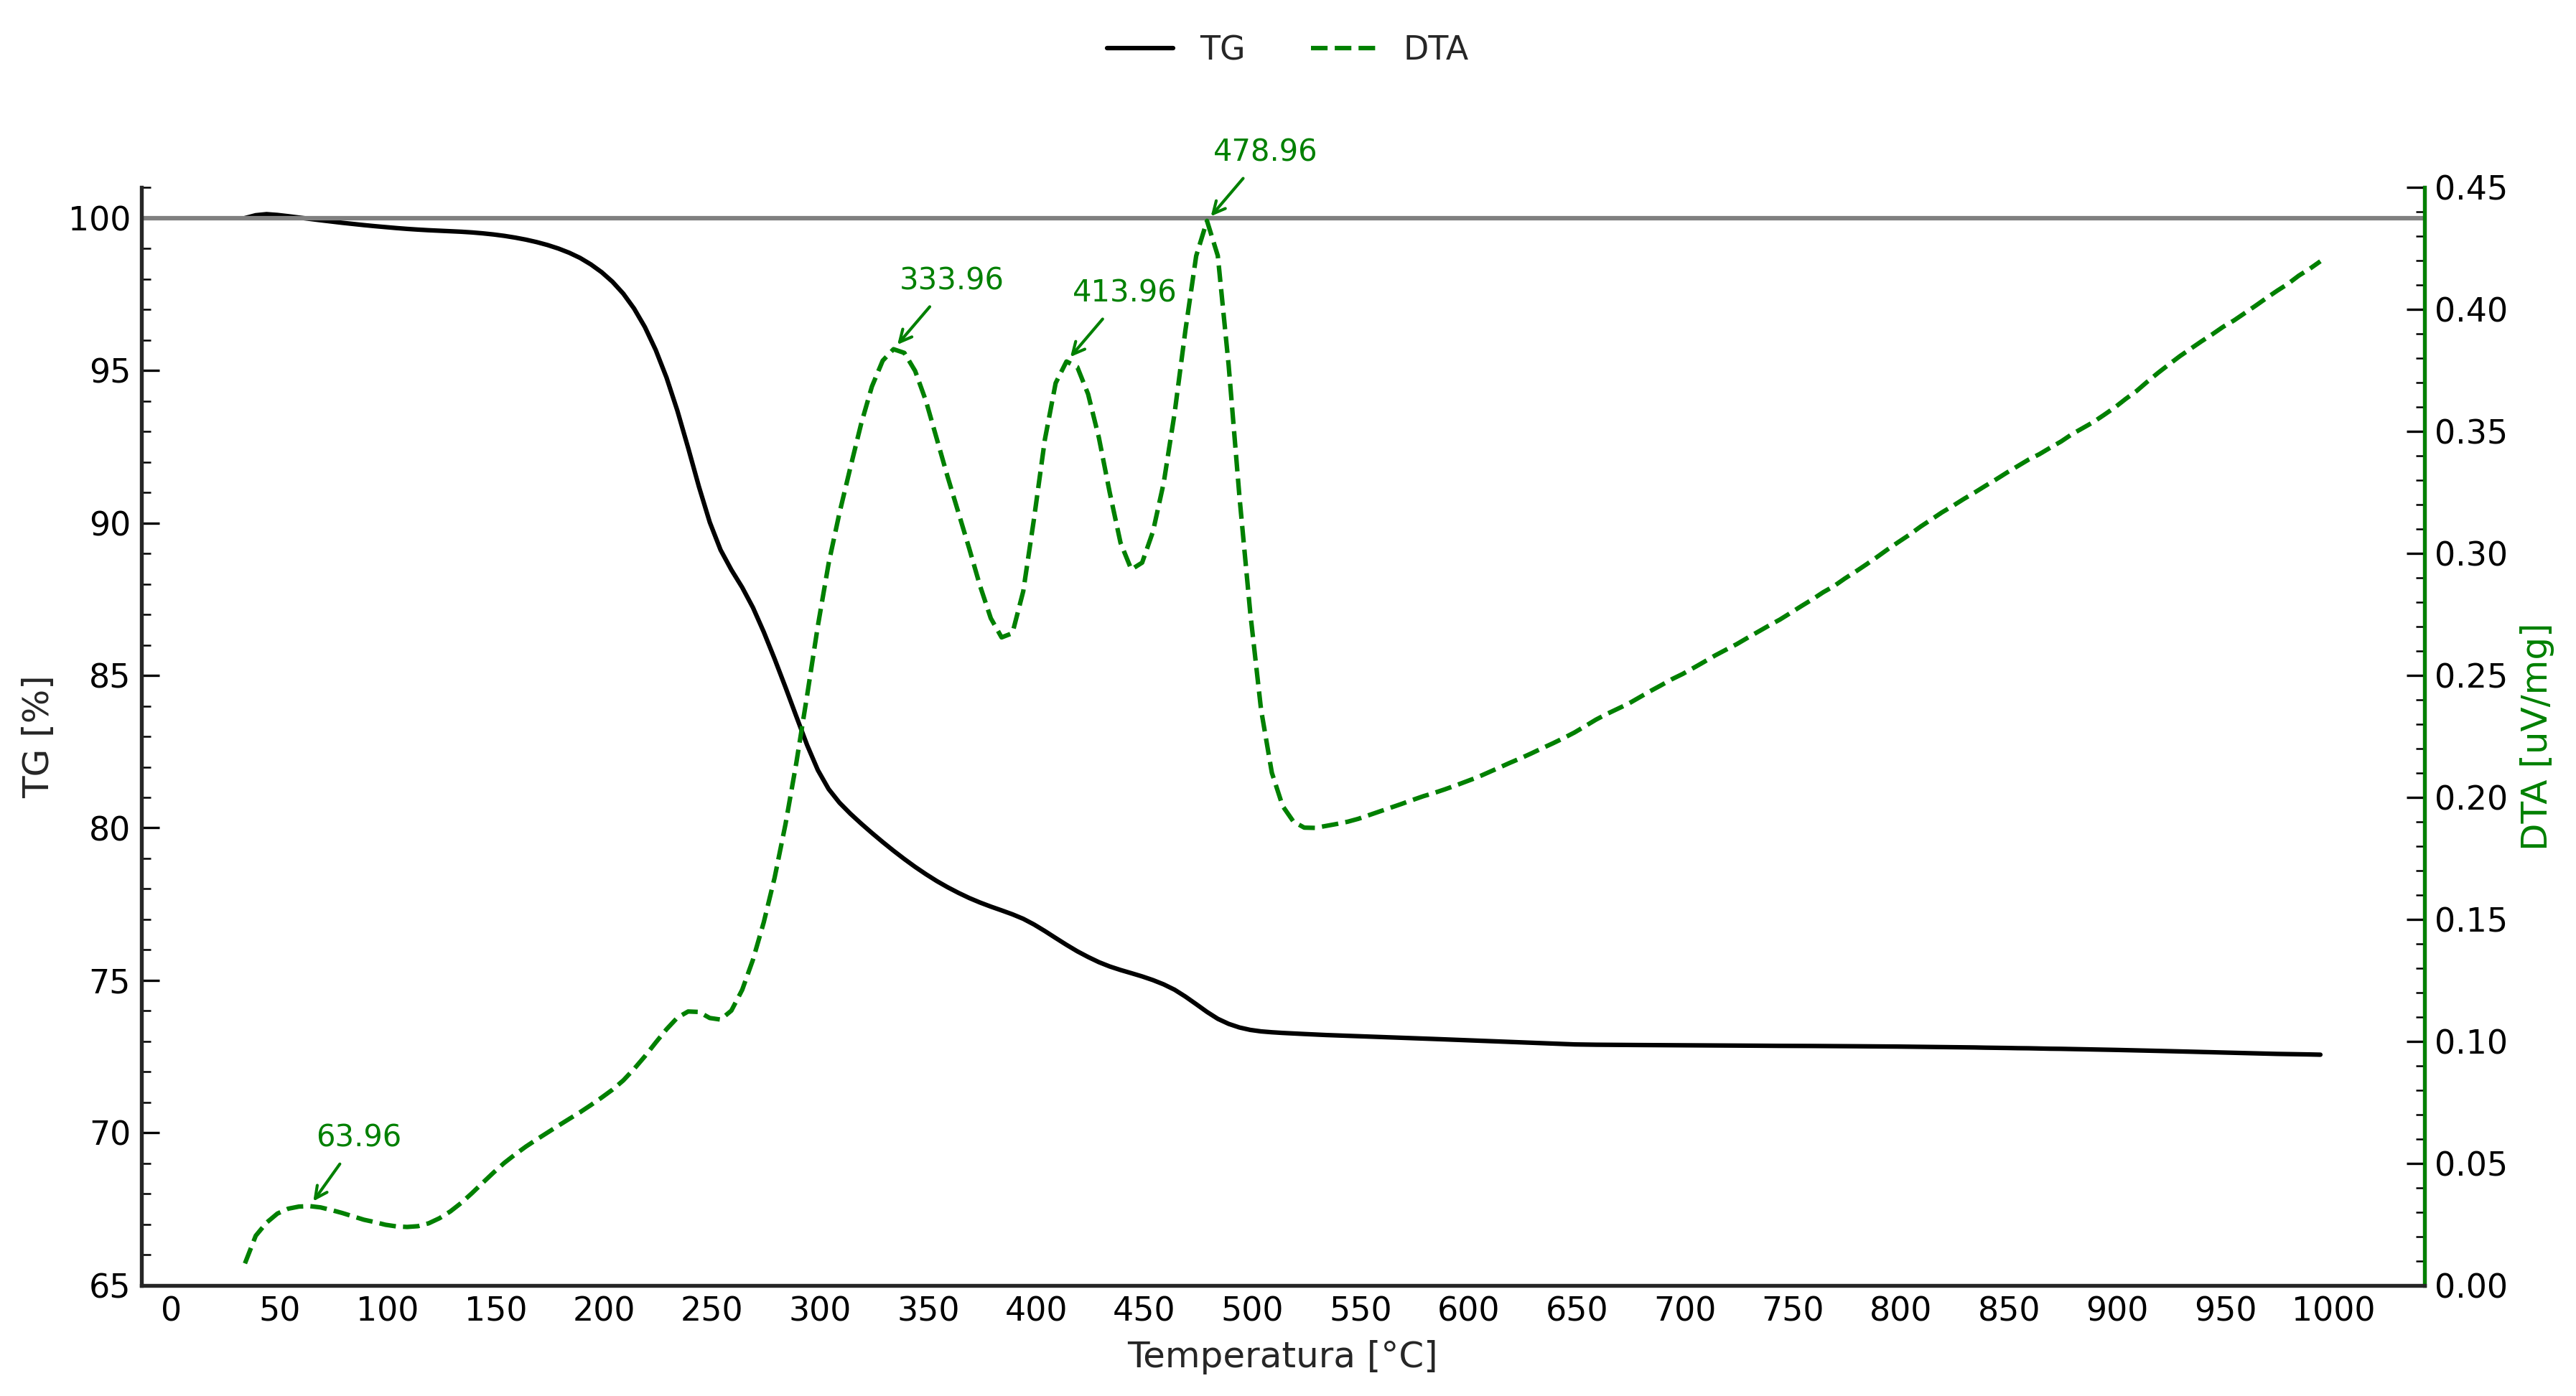

In [9]:
# wywolanie funkcji dla obu zestawów danych
plotDataset(getDataset("../datasets1/wykres1"), 65, 101, 0, 0.45,maxima_range=(50, 500))


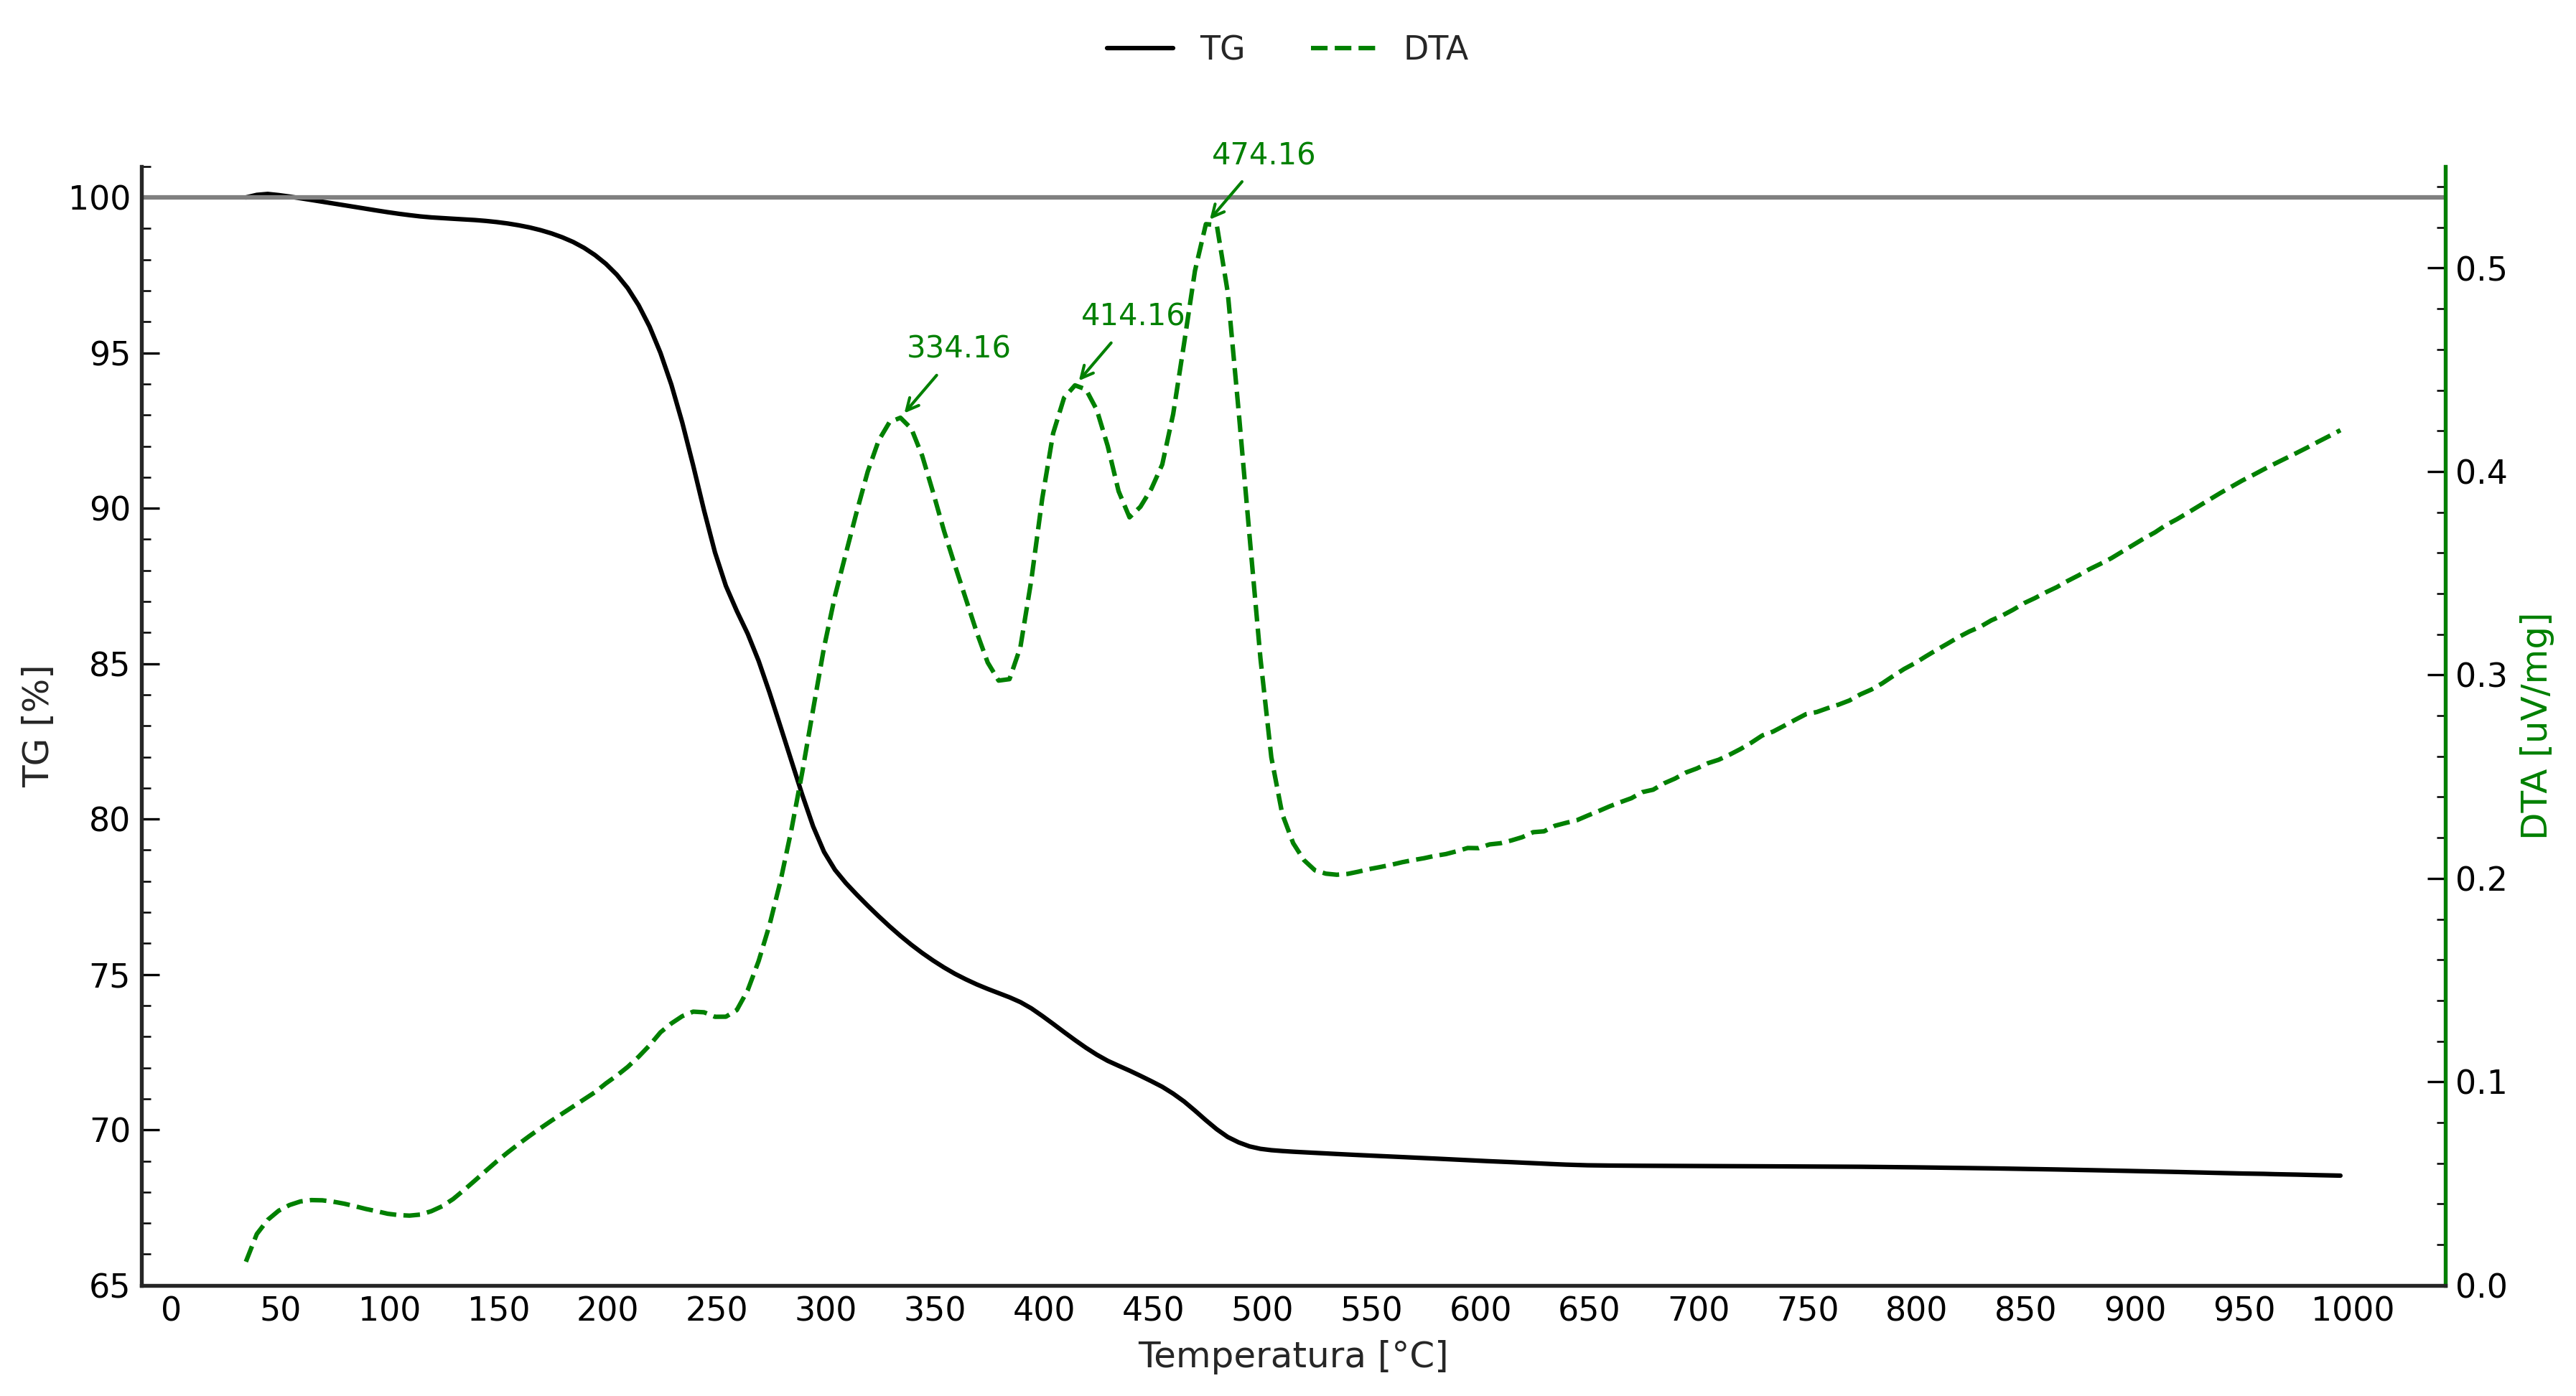

In [6]:

plotDataset(getDataset("../datasets1/wykres2"), 65, 101, 0, 0.55,maxima_range=(250, 500))

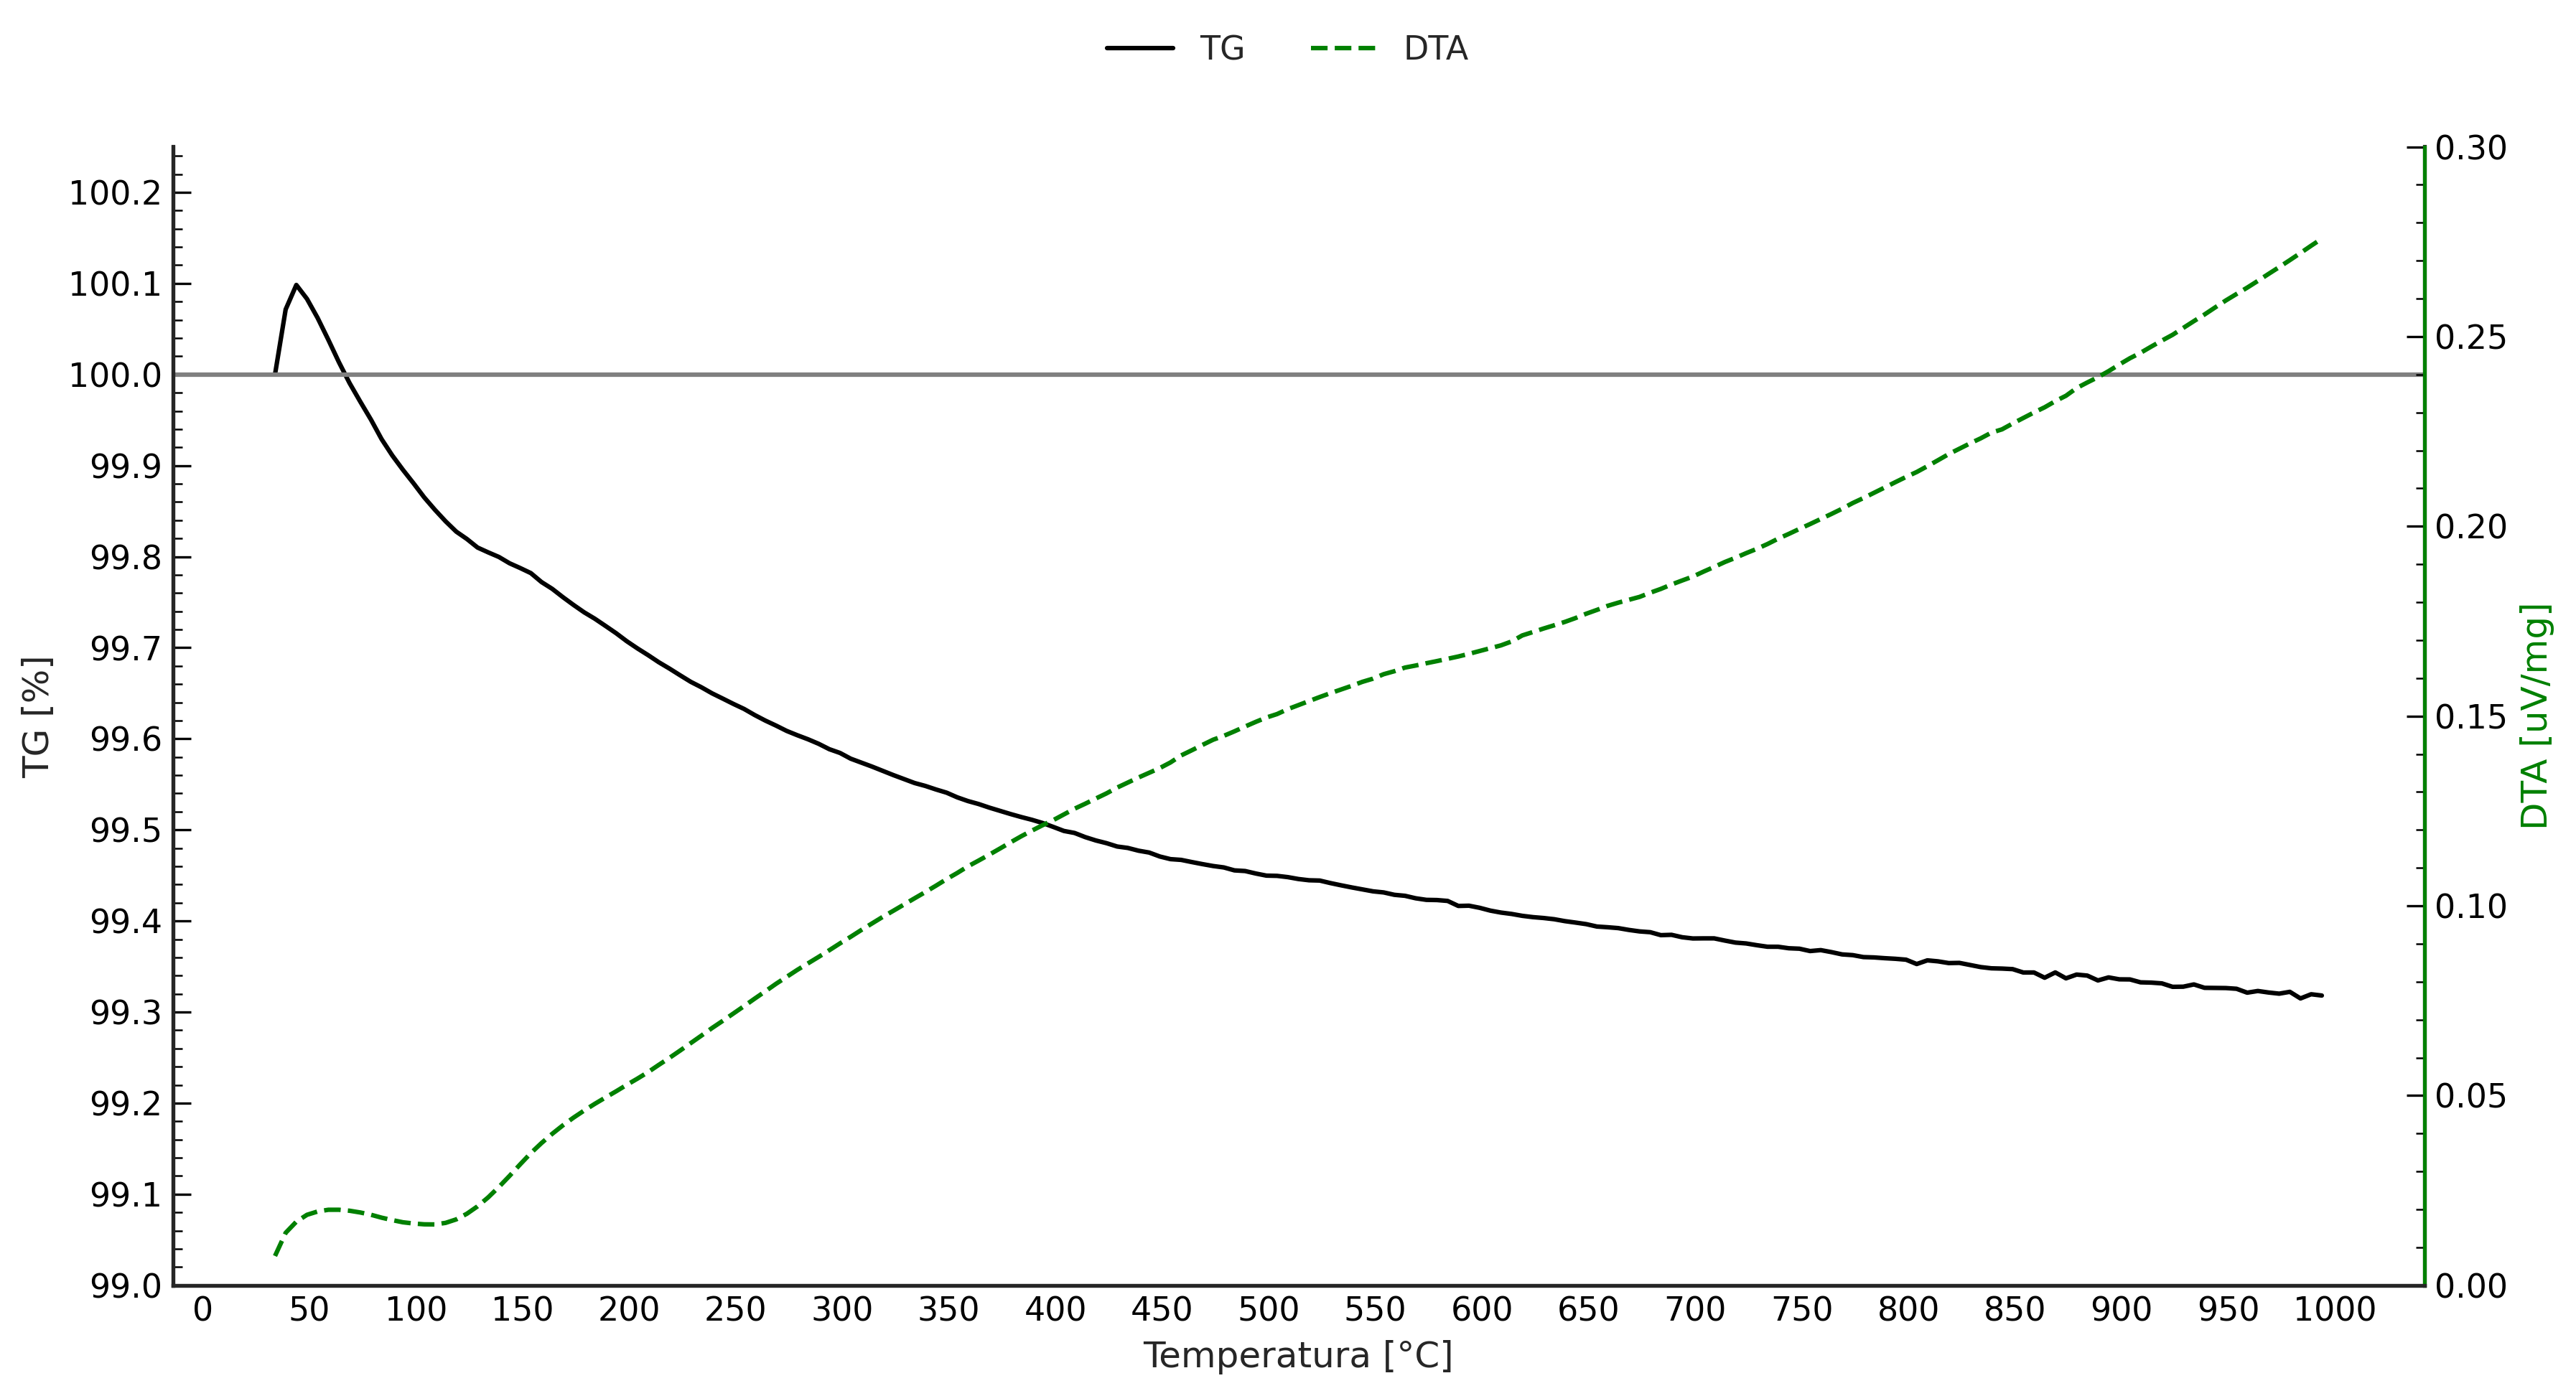

In [7]:
plotDataset(getDataset("../datasets1/wykres3"), 99, 100.25, 0, 0.30, maxima_range=(250, 500))


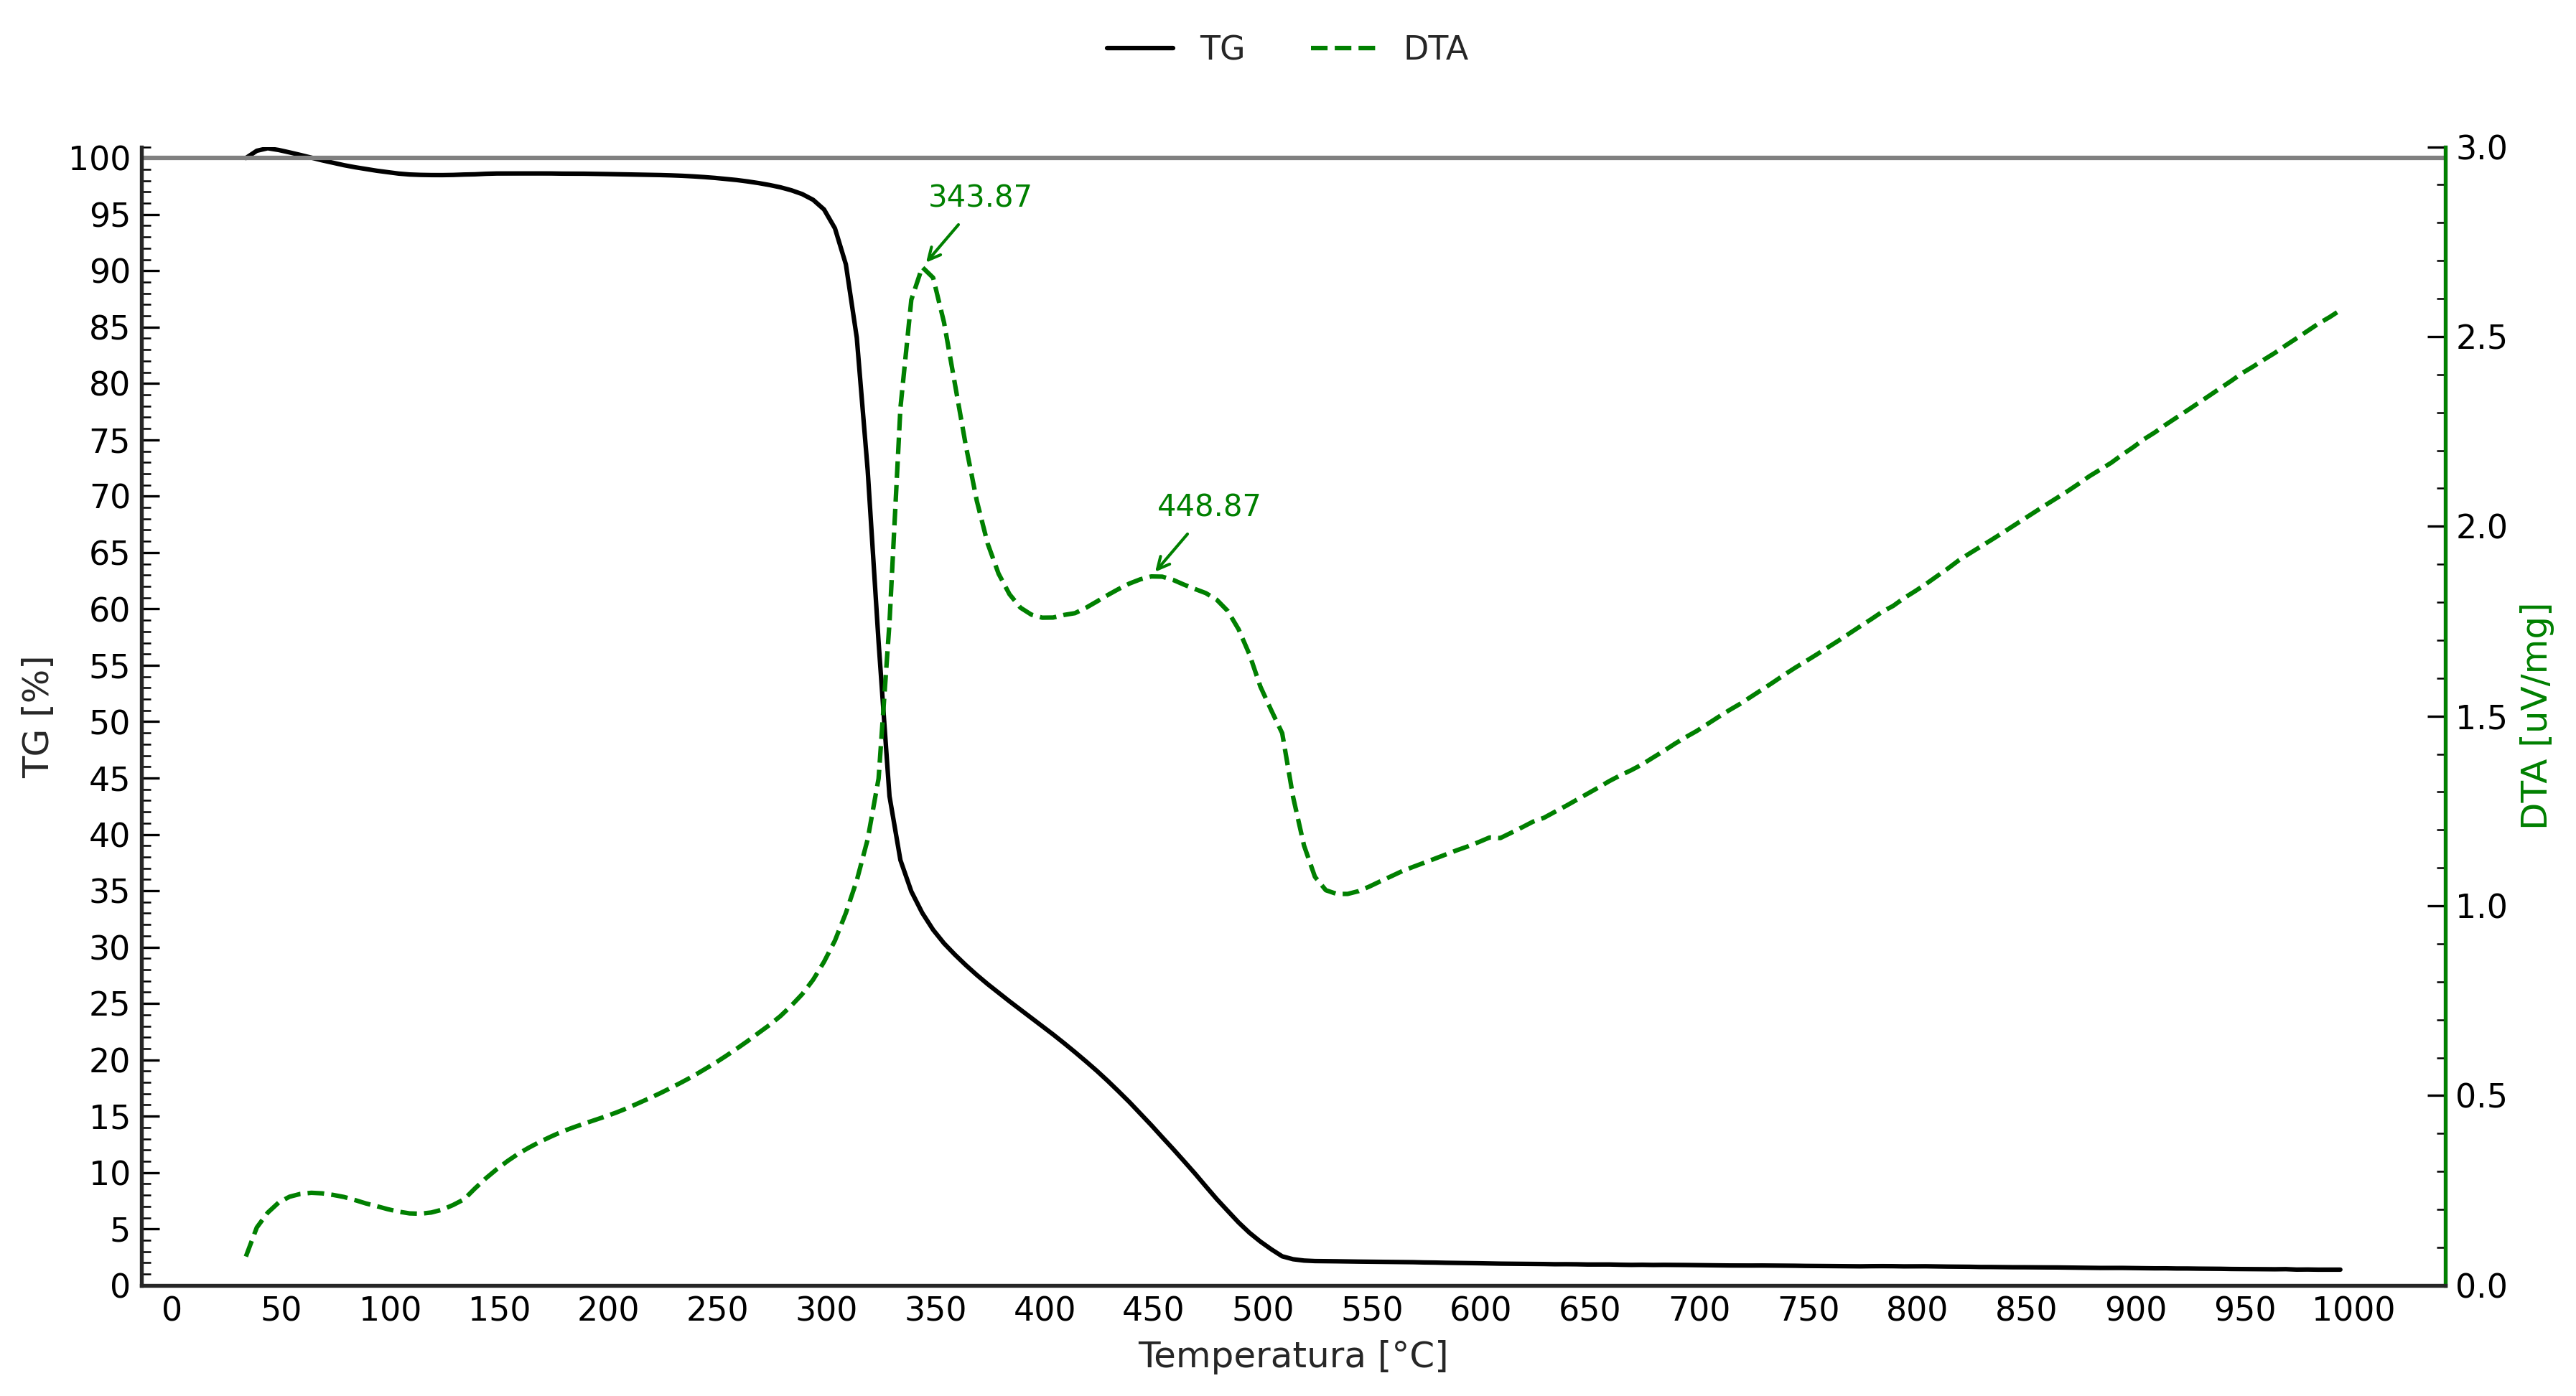

In [10]:
plotDataset(getDataset("../datasets1/wykres4"), 0, 101, 0, 3, maxima_range=(250, 460))